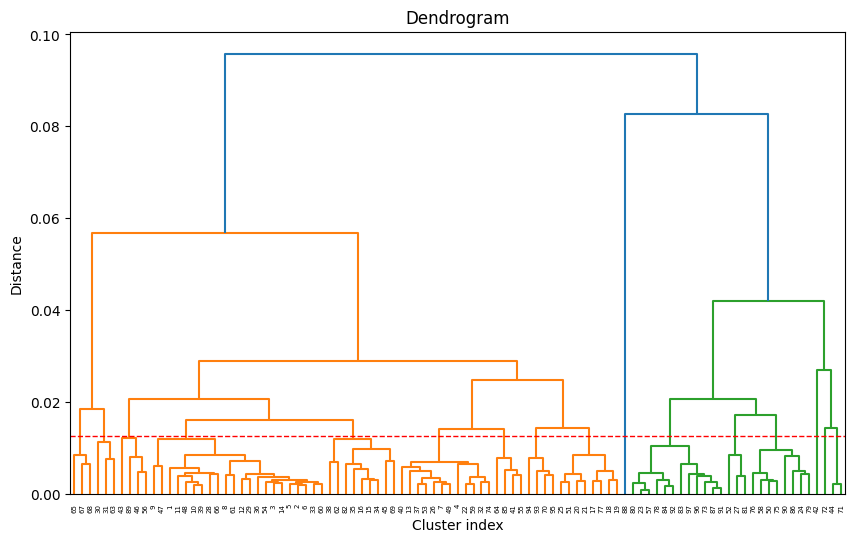

In [118]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import dendrogram
from matplotlib.collections import LineCollection
from matplotlib.colors import LinearSegmentedColormap, to_hex
import pandas as pd


# Load MATLAB linkage matrix
Z = np.loadtxt(r"Y:\Members\Mia-Sanjana-Hadent\Processed Data\042025_2mp\linkage_matlab.csv", delimiter=",")

threshold = Z[0,0]
Z = Z[1:,:]
def add_sample_counts(Z):
    """
    Add the 4th column (cluster sizes) required by SciPy dendrogram.
    Assumes Z is (n-1, 3) with 0-based indices.
    """
    Z = Z.copy()
    n = Z.shape[0] + 1

    # Create leaf labels starting at 1
    

    counts = np.zeros(Z.shape[0], dtype=int)

    for i in range(Z.shape[0]):
        c1, c2 = int(Z[i, 0]), int(Z[i, 1])

        def cluster_size(c):
            if c < n:
                return 1
            else:
                return counts[c - n]

        counts[i] = cluster_size(c1) + cluster_size(c2)

    return np.column_stack([Z, counts])


# Convert MATLAB (1-based) → Python (0-based)
Z[:, 0:2] -= 1

# Add 4th column
Z = add_sample_counts(Z)


# Plot dendrogram
plt.figure(figsize=(10, 6))

# Make cluster labels 1 to n instead of 0 to n - 1 (inclusive)
n = Z.shape[0] + 1
leaf_labels = np.arange(1, n+1)  # [1, 2, 3, ..., n]
dendrogram(Z, labels=leaf_labels)

plt.axhline(y=threshold, color="red", linestyle="--", linewidth=1)
plt.title("Dendrogram")
plt.xlabel("Cluster index")
plt.ylabel("Distance")
plt.show()


In [119]:
df = pd.read_csv(r"D:\from desktop\Hadents Folder\Visualization\Output_test_2mp\data\combined_results_2mp_with_features.csv")

Z_levels = Z.copy()
max_distance = np.max(Z[:, 2])
# Example custom thresholds (distance values)
custom_thresholds = [threshold, threshold*2, threshold*4, threshold*8]  # 4 thresholds for 5 levels
custom_thresholds = np.linspace(threshold, max_distance*0.5, 4, endpoint=False)

# Make sure they are sorted ascending
custom_thresholds = np.sort(custom_thresholds)
# Assign each merge to a level 1–5 based on custom thresholds
for i in range(Z_levels.shape[0]):
    dist = Z_levels[i, 2]
    level = np.sum(dist > custom_thresholds) + 1  # level from 1 to 5
    Z_levels[i, 2] = level


In [120]:
def get_dendogram_color_data(dendrogram_data, all_segments, final_colors):
    leaf_order = dendrogram_data['leaves']
    leaf_x_positions = []
    leaf_colors = []

    for seg, color in zip(all_segments, final_colors):
        
        # If the segment touches the bottom
        if np.any(np.isclose(seg[:, 1], 0)):
            
            # Find x coordinate at y = 0
            bottom_points = seg[np.isclose(seg[:, 1], 0)]
            
            for pt in bottom_points:
                leaf_x_positions.append(pt[0])
                leaf_colors.append(color)

    # Convert to arrays
    leaf_x_positions = np.array(leaf_x_positions)
    leaf_colors = np.array(leaf_colors)

    # Remove duplicates (multiple points can exist per leaf)
    unique_x, unique_indices = np.unique(leaf_x_positions, return_index=True)

    leaf_x_positions = unique_x
    leaf_colors = leaf_colors[unique_indices]

    # Sort left → right
    sort_idx = np.argsort(leaf_x_positions)
    leaf_x_positions = leaf_x_positions[sort_idx]
    leaf_colors = leaf_colors[sort_idx]

    # Build DataFrame
    df_leaf_colors = pd.DataFrame({
        "LeafIndex": leaf_order,
        "ClusterLabel": df['Cluster'].values[leaf_order],
        "XPosition": leaf_x_positions,
        "RGBA_Color": list(leaf_colors)
    })

    df_leaf_colors["HEX_Color"] = df_leaf_colors["RGBA_Color"].apply(to_hex)
    return df_leaf_colors


In [125]:

def dendogram_plot_with_usage(save_path, cluster_data, addon="", max_val=None):
    fig, (ax_dendro, ax_bar) = plt.subplots(
        2, 1,
        figsize=(10, 4),
        gridspec_kw={'height_ratios': [3, 2]},
        sharex=True
    )

    # -----------------------------
    # DENDROGRAM 
    # -----------------------------
    ddata = dendrogram(Z_levels, ax=ax_dendro, labels = leaf_labels)



    # Get ALL dendrogram line collections
    line_collections = [c for c in ax_dendro.collections if isinstance(c, LineCollection)]

    # Gather all segments
    all_segments = []
    segment_map = []

    for lc in line_collections:
        segments = lc.get_segments()
        for seg in segments:
            all_segments.append(seg)
            segment_map.append(lc)

    # Identify vertical segments and store their indices
    vertical_indices = []
    vertical_x = []

    for i, seg in enumerate(all_segments):
        # A segment is vertical if x values are equal
        if np.allclose(seg[0, 0], seg[1, 0]):
            vertical_indices.append(i)
            vertical_x.append(seg[0, 0])

    vertical_x = np.array(vertical_x)

    # Normalize x positions (left → right)
    x_min = vertical_x.min()
    x_max = vertical_x.max()
    x_norm = (vertical_x - x_min) / (x_max - x_min)

    # Custom gradient
    cmap = LinearSegmentedColormap.from_list(
        "custom_gradient",
        ["#eec42b", "#61b751", "#2a84df", "#dd077a"]
    )

    # Create full color list (default gray for all)
    final_colors = [(0.7, 0.7, 0.7, 1)] * len(all_segments)

    # Assign gradient only to vertical segments
    for idx, norm_val in zip(vertical_indices, x_norm):
        final_colors[idx] = cmap(norm_val)

    # Apply colors back
    start = 0
    for lc in line_collections:
        lc.set_linewidth(2)
        seg_count = len(lc.get_segments())
        lc.set_color(final_colors[start:start + seg_count])
        start += seg_count

    # Styling
    ax_dendro.spines['bottom'].set_visible(False)
    ax_dendro.set_ylabel("Hierarchy Level")
    ax_dendro.set_yticks(range(1, 6))
    ax_dendro.set_yticklabels(list(range(5, 0, -1)))
    ax_dendro.set_title("5-Level Hierarchy Dendrogram" + addon)
    ax_dendro.tick_params(axis='x', length=0, labelsize=6)

    df_leaf_colors = get_dendogram_color_data(ddata, all_segments, final_colors)

    # -----------------------------
    # BAR GRAPH (ALIGNED TO LEAVES)
    # -----------------------------

    # 2️⃣ Map each leaf (in dendrogram order) to the cluster's mean
    leaf_order = ddata['leaves']
    ordered_clusters = df['Cluster'].values[leaf_order]

    # Map cluster label → mean acceleration
    bar_values = []
    for label in leaf_order:
        label = label + 1
        if not label in cluster_data:
            bar_values.append(0)
            continue
        bar_values.append(cluster_data[label])

    # 3️⃣ Bar positions (aligned to dendrogram leaves)
    x_positions = np.arange(len(ordered_clusters)) * 10 + 5

    # 4️⃣ Plot
    bar_colors = df_leaf_colors["RGBA_Color"].tolist()  # keep colors
    ax_bar.bar(x_positions, bar_values, width=8, color=bar_colors)

    ax_bar.set_ylabel("Cluster Usage %")
    ax_bar.spines['top'].set_visible(False)
    ax_bar.spines['right'].set_visible(False)
    ax_bar.invert_yaxis()  # optional
    ax_bar.xaxis.set_visible(False)
    #ax_bar.spines['bottom'].set_visible(False)
    ax_bar.set_ylim(6 * 1.1)
    if max_val:
        ax_bar.set_ylim(max_val * 1.1)
    
    # Save as PNG
    fig.savefig(save_path, dpi=300, bbox_inches='tight')

    plt.tight_layout()
    plt.show()
    return max(bar_values)

In [126]:
stages = []
week_numbers = df["Week_Number"].unique()

for week in week_numbers:
    week_data = df[df["Week_Number"] == week]
    stages.append(week_data)

In [127]:


#cluster_acc = df.groupby('Cluster')['TotAccelBA'].mean()
# Count how many leaves are in each cluster
cluster_counts = df.groupby('Cluster').size()
tot_cluster_sum = cluster_counts.sum()
# Convert to percentage
cluster_percent = cluster_counts / cluster_counts.sum() * 100
max_cluster_percentage = cluster_percent.max()

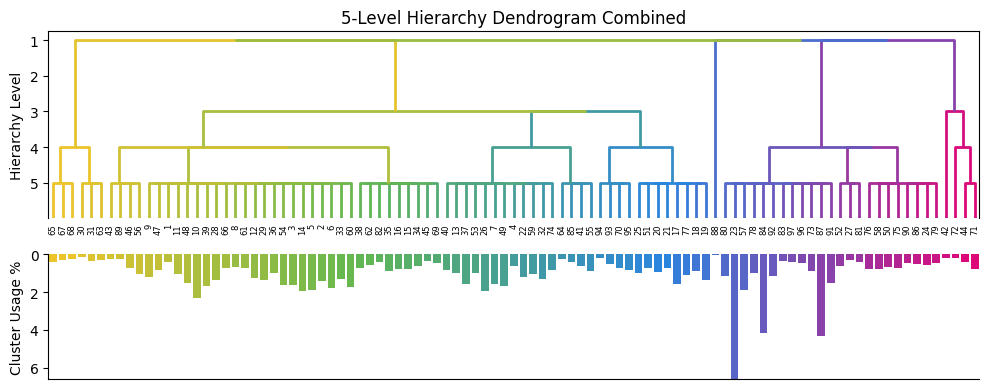

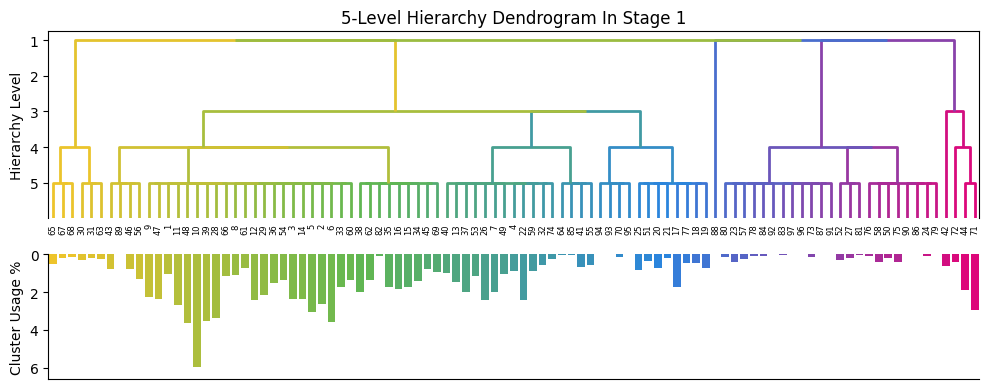

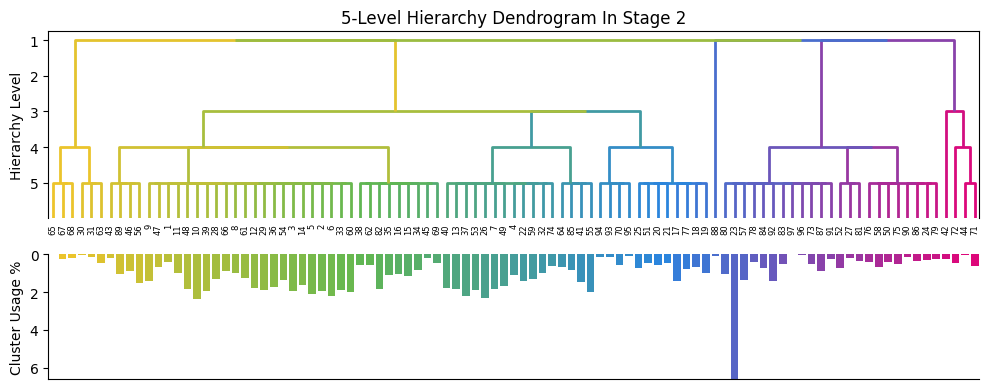

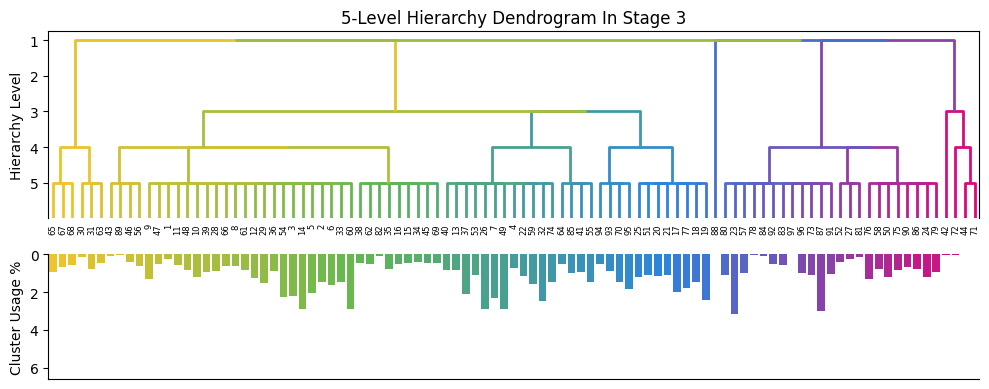

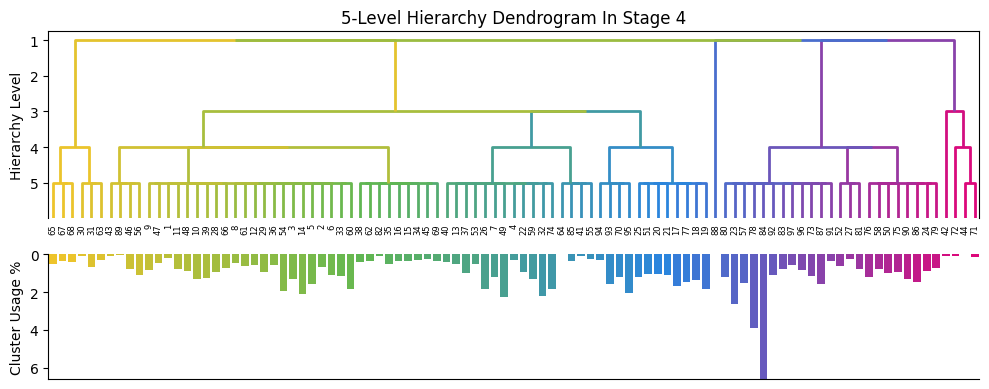

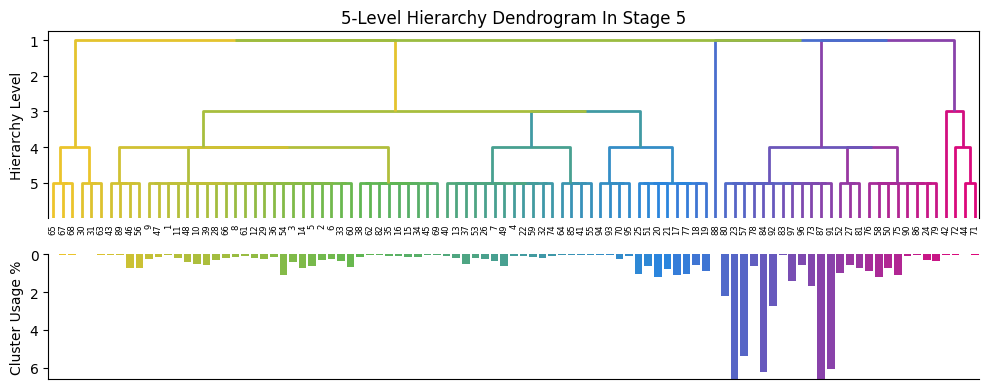

In [128]:

max_val = None
for i in range(6):
    if i == 0:
        filename = "Hierarchy_Dendogram_Usage.png"
        cluster_acc = df.groupby('Cluster').size()
        # Count how many leaves are in each cluster
        cluster_counts = df.groupby('Cluster').size()
        addon=" Combined"
    else:
        filename = f"Hierarchy_Dendogram_Usage_Stage_{i}.png"
        cluster_acc = stages[i-1].groupby('Cluster').size()
        # Count how many leaves are in each cluster
        cluster_counts = stages[i-1].groupby('Cluster').size()
        addon=f" In Stage {i}"

    # Convert to percentage
    cluster_percent = cluster_counts / cluster_counts.sum() * 100
    dendogram_plot_with_usage(filename, cluster_percent, addon=addon)